## 1. Loading the data and configuring the analysis

This notebook starts by importing the libraries needed for exploratory data analysis and loading the California Housing dataset. After that, we set the visual style to keep the plots consistent and readable.

The goal is to understand the structure of the data, identify patterns, and evaluate which variables are most relevant for predicting housing prices.

## Overview
We loaded the California Housing dataset and reviewed the data structure, columns, and basic statistics. The goal was to understand what drives house prices before building a model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import DADOS_ORIGINAIS, DADOS_LIMPOS
from src.graficos import PALETTE, SCATTER_ALPHA

sns.set_theme(palette="bright")

In [2]:
df = pd.read_csv(DADOS_ORIGINAIS, compression='zip')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## Main findings
`median_income` is the strongest signal in the data. We also saw skewed variables, outliers, and an imbalanced `ocean_proximity` distribution.

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.describe(exclude=['number'])

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


## 2. First look at the categorical variable

The `ocean_proximity` variable is a categorical feature that groups properties by their location relative to the ocean. It is important to inspect its distribution because the categories may have different price patterns and data volumes.

This analysis reveals that most observations are concentrated in the `<1H OCEAN` category, while some categories, such as `ISLAND`, contain only a few samples.

In [7]:
# Identificado: 1- ~50% dos valores acumulados em "<1H OCEAN", e 2- Apenas 5 valores em "ISLAND"
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## Considerations
We removed extreme values and created new features like rooms per household and bedrooms per room. This helps the model learn more meaningful patterns.

## 3. Univariate distributions and asymmetry

The next step is to analyze the shape of the numerical variables. We inspect skewness and kurtosis to understand if the variables are symmetric or heavily tailed.

This is important because skewed variables can affect linear models and may require transformations or careful preprocessing before training.

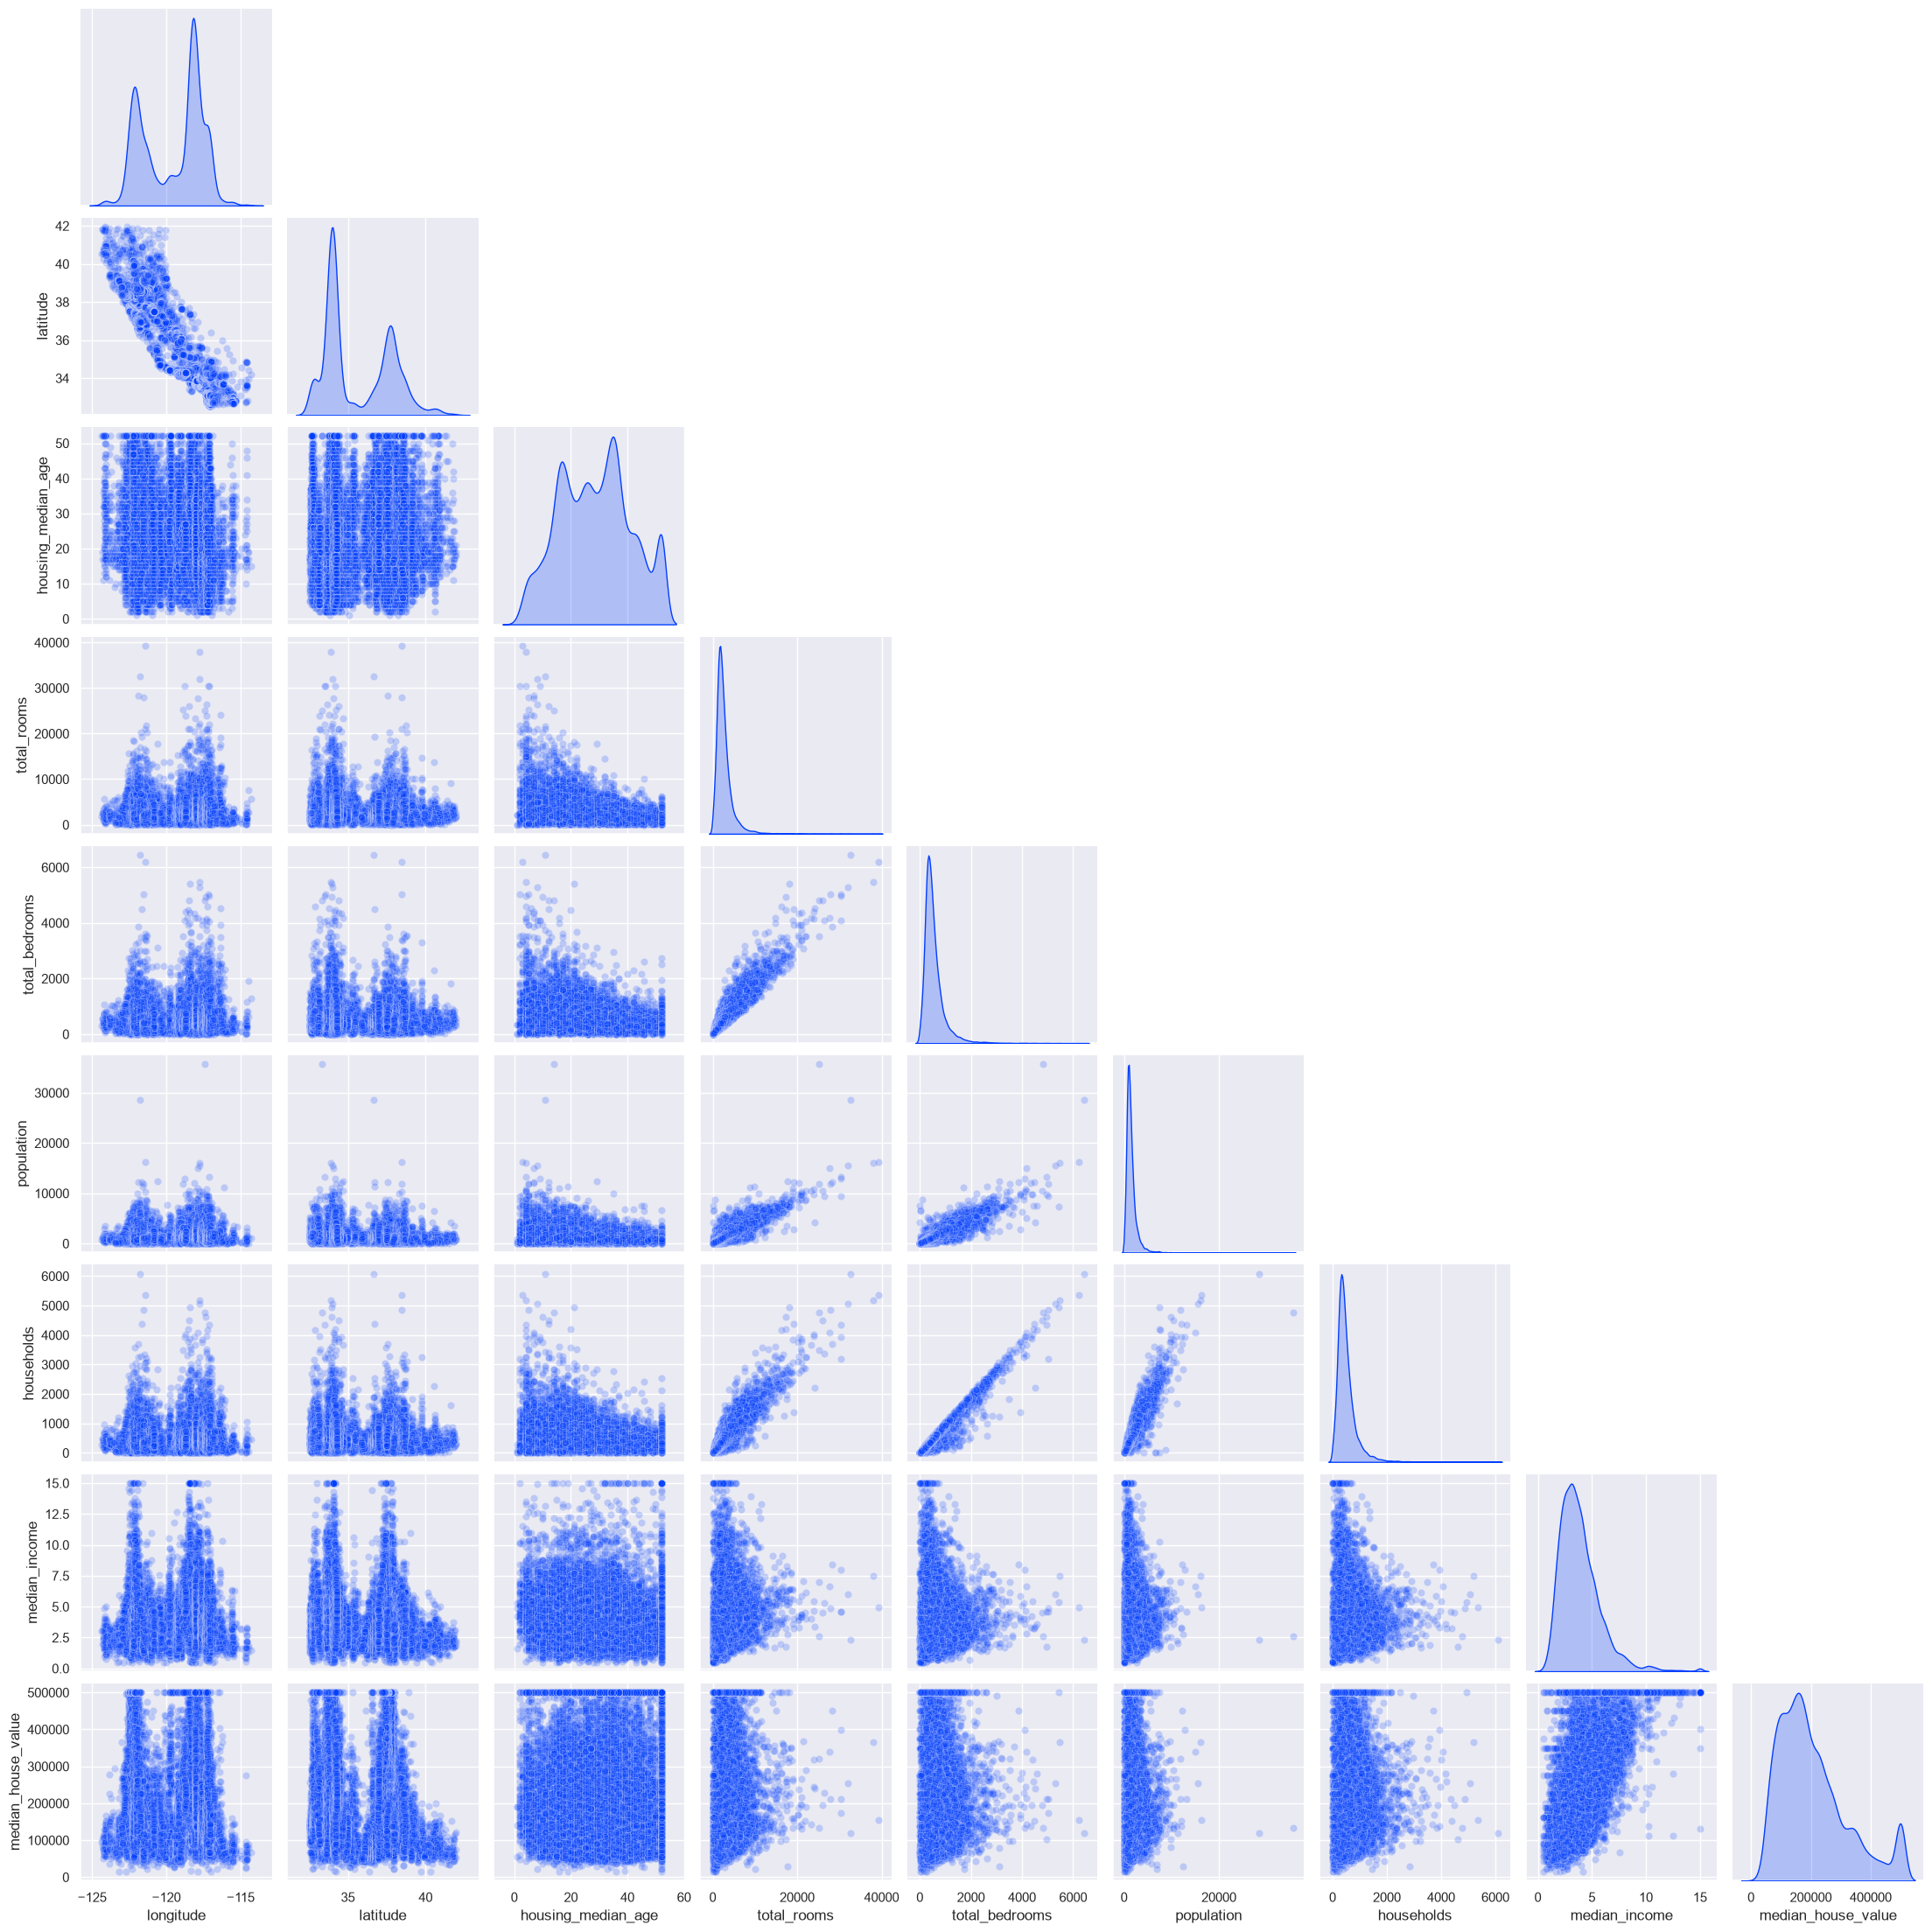

In [8]:
sns.pairplot(df, diag_kind="kde", corner=True, plot_kws=dict(alpha=0.2))

In [9]:
# Checking the skewness of numerical variables
# Skew = 0 indicates a symmetric distribution | Positive skew → right-tailed distribution | Negative skew → left-tailed distribution
# 2 peaks are considered bimodal | 1 peak is unimodal  and 0 peaks indicate a uniform distribution

df.select_dtypes('number').skew()

longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.459546
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64

In [10]:
# Checking the kurtosis of numerical variables
# Kurtosis = 0 indicates a normal distribution
# Positive kurtosis → heavier tails (more extreme values/outliers)
# Negative kurtosis → lighter tails (fewer extreme values/outliers)
df.select_dtypes('number').kurtosis()

longitude             -1.330152
latitude              -1.117760
housing_median_age    -0.800629
total_rooms           32.630927
total_bedrooms        21.985575
population            73.553116
households            22.057988
median_income          4.952524
median_house_value     0.327870
dtype: float64

In [11]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [12]:
df[df.isnull().any(axis=1)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [13]:
df[df.isnull().any(axis=1)].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,207.000000,207.000000,207.000000,207.000000,0.0,207.000000,207.000000,207.000000,207.000000
mean,-119.472560,35.497633,29.270531,2562.603865,NaN,1477.772947,510.024155,3.822244,206007.280193
std,2.001424,2.097298,11.964927,1787.269789,NaN,1057.448212,386.120704,1.955595,111638.214545
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.810000,33.970000,19.000000,1307.500000,NaN,781.000000,258.000000,2.564150,128750.000000
50%,-118.490000,34.200000,30.000000,2155.000000,NaN,1217.000000,427.000000,3.411500,175000.000000
75%,-117.985000,37.495000,38.000000,3465.000000,NaN,1889.500000,628.000000,4.615750,267700.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


In [14]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

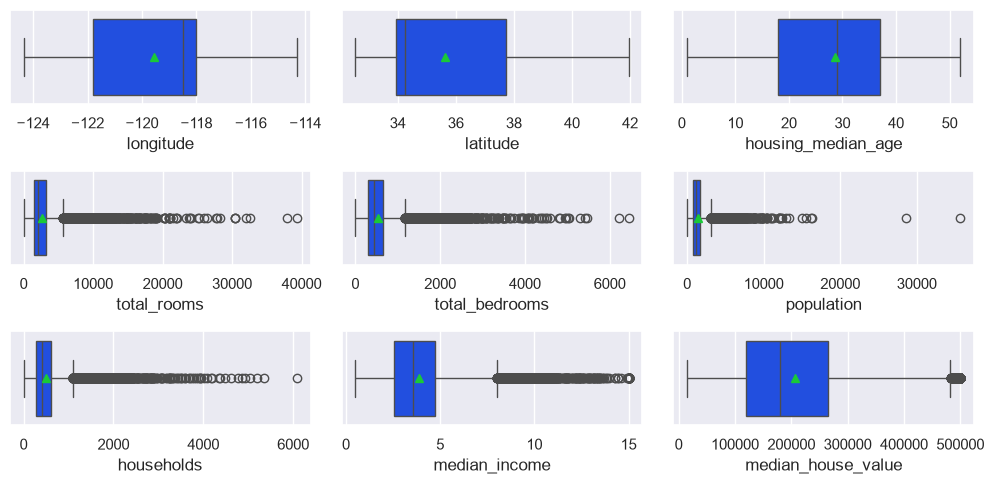

In [15]:
fig, axs = plt.subplots(3, 3, figsize=(10, 5))

for ax, column in zip(axs.flatten(), df.columns):
    sns.boxplot(data=df,x=column, ax=ax, showmeans=True)

plt.tight_layout()
plt.show()

## 4. Correlation analysis

The correlation matrix helps us understand how strongly the numerical variables are related to each other. This is especially useful in real estate datasets, where features like size, occupancy, and income can be highly correlated.

The main insight from this step is that `median_income` shows the strongest relationship with the target variable, while some variables are strongly correlated with each other.

<Axes: >

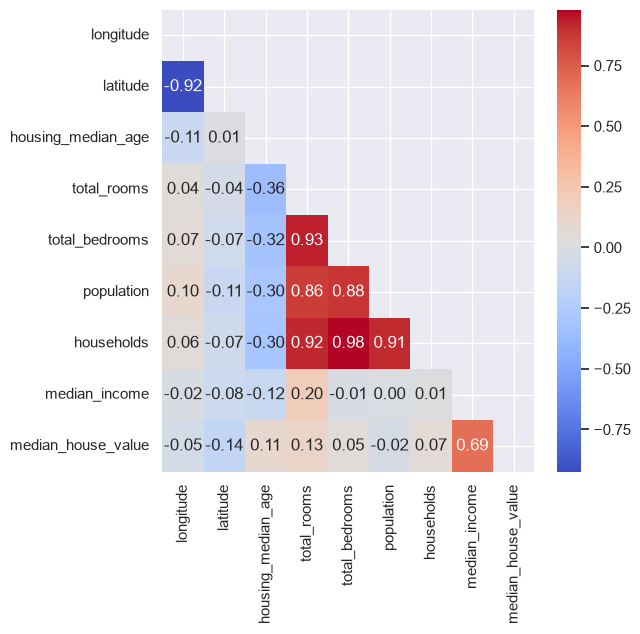

In [16]:
matriz = np.triu(df.select_dtypes('number').corr())

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=matriz,
    ax=ax,
    
)

The only feature with a strong relationship to the target variable is `median_income`. Therefore, it makes sense to perform some feature engineering to create new variables that may better capture patterns in the data:
 
- Create income categories based on `median_income`
- Rooms per household
- People per household
- Bedrooms per room

In [17]:
df['median_income_cat'] = pd.cut(
    df['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5],
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  str     
 10  median_income_cat   20640 non-null  category
dtypes: category(1), float64(9), str(1)
memory usage: 1.8 MB


In [18]:
df["median_income_cat"].value_counts().sort_index()

median_income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64

<Axes: title={'center': 'Median Income Category Distribution'}, xlabel='median_income_cat'>

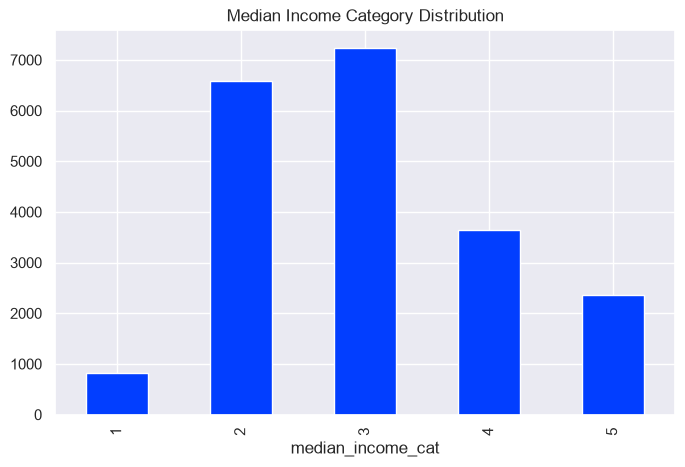

In [19]:
df['median_income_cat'].value_counts().sort_index().plot(kind='bar', figsize=(8, 5), title='Median Income Category Distribution')

In [20]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'median_income_cat'],
      dtype='str')

## 5. Feature engineering

The raw variables provide useful information, but some relationships are clearer when expressed as ratios or categories. For example, the number of rooms per household, the number of people per household, and bedroom-to-room ratios often capture housing characteristics more effectively than the original counts alone.

This is the moment where we start creating more informative features that can improve the model later on.

### Creating new columns to improve the Model

In [21]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 20640 non-null  float64 
 1   latitude                  20640 non-null  float64 
 2   housing_median_age        20640 non-null  float64 
 3   total_rooms               20640 non-null  float64 
 4   total_bedrooms            20433 non-null  float64 
 5   population                20640 non-null  float64 
 6   households                20640 non-null  float64 
 7   median_income             20640 non-null  float64 
 8   median_house_value        20640 non-null  float64 
 9   ocean_proximity           20640 non-null  str     
 10  median_income_cat         20640 non-null  category
 11  rooms_per_household       20640 non-null  float64 
 12  population_per_household  20640 non-null  float64 
 13  bedrooms_per_room         20433 non-null  float64 
dtypes

In [22]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,5.429000,3.070655,0.213039
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,2.474173,10.386050,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.692308,0.100000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,4.440716,2.429741,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129,2.818116,0.203162
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,6.052381,3.282261,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1243.333333,1.000000


## 6. EDA after feature engineering

After generating the new variables, we repeat the exploratory analysis to verify if they add useful information. This step checks whether the engineered features improve interpretability and whether their distributions are reasonable for modeling.

The key idea is to understand how these new variables interact with the target before moving to modeling.

### EDA for new columns

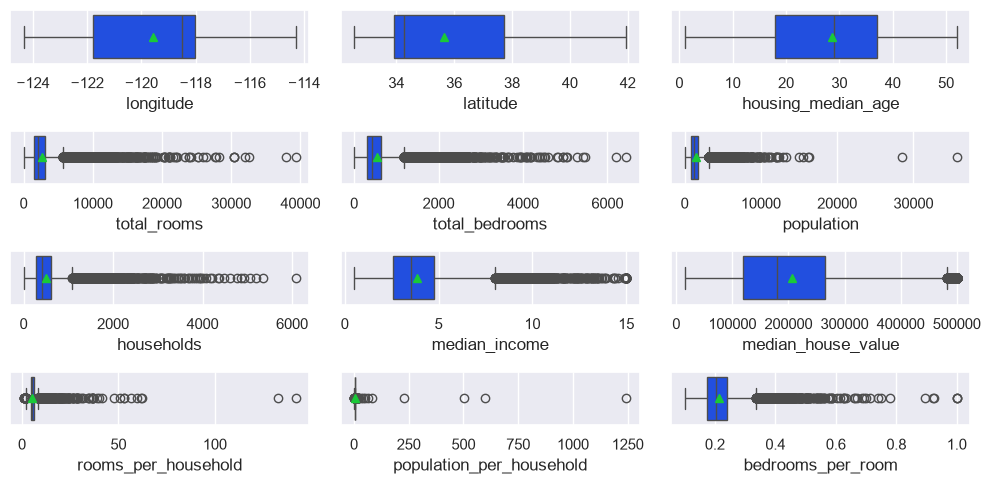

In [23]:
fig, axs = plt.subplots(4, 3, figsize=(10, 5))

for ax, column in zip(axs.flatten(), df.select_dtypes('number').columns):
    sns.boxplot(data=df, x=column, ax=ax, showmeans=True)

plt.tight_layout()
plt.show()

<Axes: >

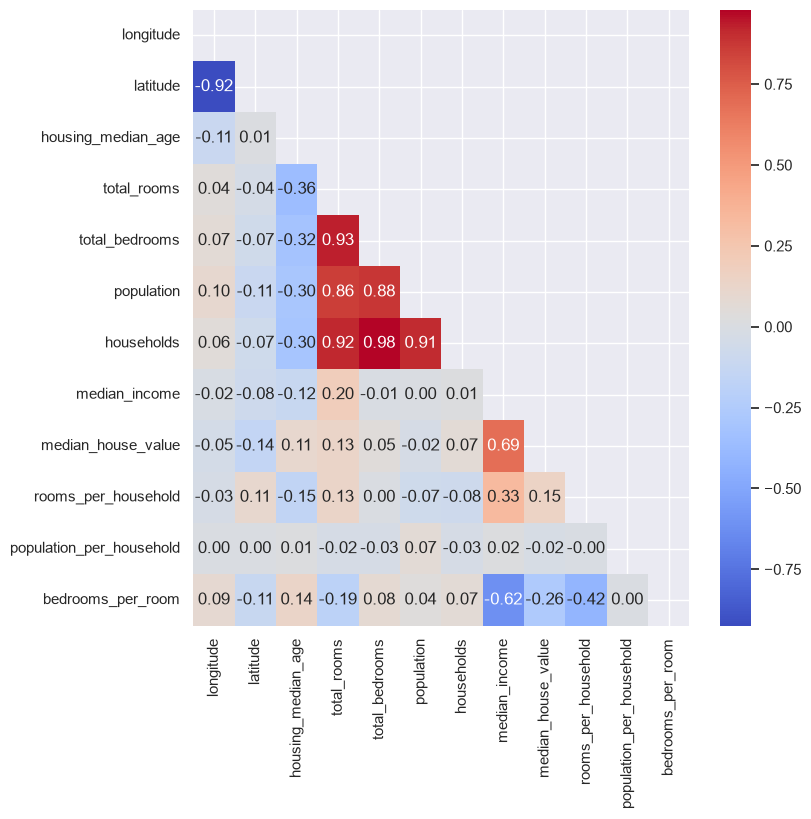

In [24]:
matriz = np.triu(df.select_dtypes('number').corr())

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=matriz,
    ax=ax,
    
)

## 7. Detecting extreme values

The target variable `median_house_value` has a maximum value of `500001.0`, which is much higher than most observations. This suggests that a small percentage of the sample contains extreme values, which can distort model behavior and overestimate the importance of specific records.

At this point, we identify the proportion of extreme values and decide how to filter them to improve model quality.

### Identifying the target max value 
The max value found is 500001.0, and made up 4.6 % of the sample. It shows the data should have been cut when it was exported.

In [25]:
df[
    df['median_house_value'] == df['median_house_value'].max()
]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
89,-122.27,37.80,52.0,249.0,78.0,396.0,85.0,1.2434,500001.0,NEAR BAY,1,2.929412,4.658824,0.313253
459,-122.25,37.87,52.0,609.0,236.0,1349.0,250.0,1.1696,500001.0,NEAR BAY,1,2.436000,5.396000,0.387521
493,-122.24,37.86,52.0,1668.0,225.0,517.0,214.0,7.8521,500001.0,NEAR BAY,5,7.794393,2.415888,0.134892
494,-122.24,37.85,52.0,3726.0,474.0,1366.0,496.0,9.3959,500001.0,NEAR BAY,5,7.512097,2.754032,0.127214
509,-122.23,37.83,52.0,2990.0,379.0,947.0,361.0,7.8772,500001.0,NEAR BAY,5,8.282548,2.623269,0.126756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20422,-118.90,34.14,35.0,1503.0,263.0,576.0,216.0,5.1457,500001.0,<1H OCEAN,4,6.958333,2.666667,0.174983
20426,-118.69,34.18,11.0,1177.0,138.0,415.0,119.0,10.0472,500001.0,<1H OCEAN,5,9.890756,3.487395,0.117247
20427,-118.80,34.19,4.0,15572.0,2222.0,5495.0,2152.0,8.6499,500001.0,<1H OCEAN,5,7.236059,2.553439,0.142692
20436,-118.69,34.21,10.0,3663.0,409.0,1179.0,371.0,12.5420,500001.0,<1H OCEAN,5,9.873315,3.177898,0.111657


In [26]:
965 / df.shape[0]

0.04675387596899225

In [27]:
df['median_house_value'].quantile(0.95 )

np.float64(489809.9999999999)

## 8. Filtering extreme records

To reduce noise and improve stability, we remove the most extreme observations using quantile thresholds. This keeps the dataset more representative while avoiding the influence of a few very high-value properties.

This step is common in real-world predictive projects because extreme values can make the model less generalizable.

In [28]:
df_clean = df.copy()

In [29]:
quantile = 0.99

df_clean = df_clean[
    (df['median_house_value'] < df['median_house_value'].quantile(quantile))
    & (df['total_bedrooms'] < df['total_bedrooms'].quantile(quantile))
    & (df['total_rooms'] < df['total_rooms'].quantile(quantile))
    & (df['population'] < df['population'].quantile(quantile))
    & (df['households'] < df['households'].quantile(quantile))
    & (df['median_income'] < df['median_income'].quantile(quantile))
    & (df['housing_median_age'] < df['housing_median_age'].quantile(quantile))
    & (df['rooms_per_household'] < df['rooms_per_household'].quantile(quantile))
    & (df['population_per_household'] < df['population_per_household'].quantile(quantile))
    & (df['bedrooms_per_room'] < df['bedrooms_per_room'].quantile(quantile))
]

df_clean.info()

<class 'pandas.DataFrame'>
Index: 17566 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17566 non-null  float64 
 1   latitude                  17566 non-null  float64 
 2   housing_median_age        17566 non-null  float64 
 3   total_rooms               17566 non-null  float64 
 4   total_bedrooms            17566 non-null  float64 
 5   population                17566 non-null  float64 
 6   households                17566 non-null  float64 
 7   median_income             17566 non-null  float64 
 8   median_house_value        17566 non-null  float64 
 9   ocean_proximity           17566 non-null  str     
 10  median_income_cat         17566 non-null  category
 11  rooms_per_household       17566 non-null  float64 
 12  population_per_household  17566 non-null  float64 
 13  bedrooms_per_room         17566 non-null  float64 
dtypes: cat

In [30]:
# Proportion of data retained after cleaning
1 - df_clean.shape[0] / df.shape[0]

0.14893410852713174

In [31]:
df_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room
count,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000,17566.000000
mean,-119.509858,35.601950,27.276955,2510.361152,515.361209,1386.223557,483.953034,3.696453,189591.204486,5.253849,2.934597,0.211654
std,1.984173,2.147246,11.323320,1593.957111,320.838680,844.886263,295.554440,1.541904,95988.907554,1.134053,0.691400,0.048323
min,-124.300000,32.540000,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,14999.000000,1.714286,0.750000,0.113535
25%,-121.600000,33.920000,18.000000,1464.250000,300.000000,816.000000,287.000000,2.547325,114300.000000,4.446441,2.470168,0.176919
50%,-118.460000,34.240000,28.000000,2131.000000,438.000000,1196.000000,415.000000,3.479200,171400.000000,5.205218,2.852579,0.203474
75%,-117.980000,37.670000,36.000000,3124.000000,643.000000,1738.000000,605.000000,4.622150,243800.000000,5.960973,3.306344,0.239171
max,-114.550000,41.950000,51.000000,11026.000000,2205.000000,5804.000000,1979.000000,10.594100,500000.000000,10.352941,5.392954,0.406295


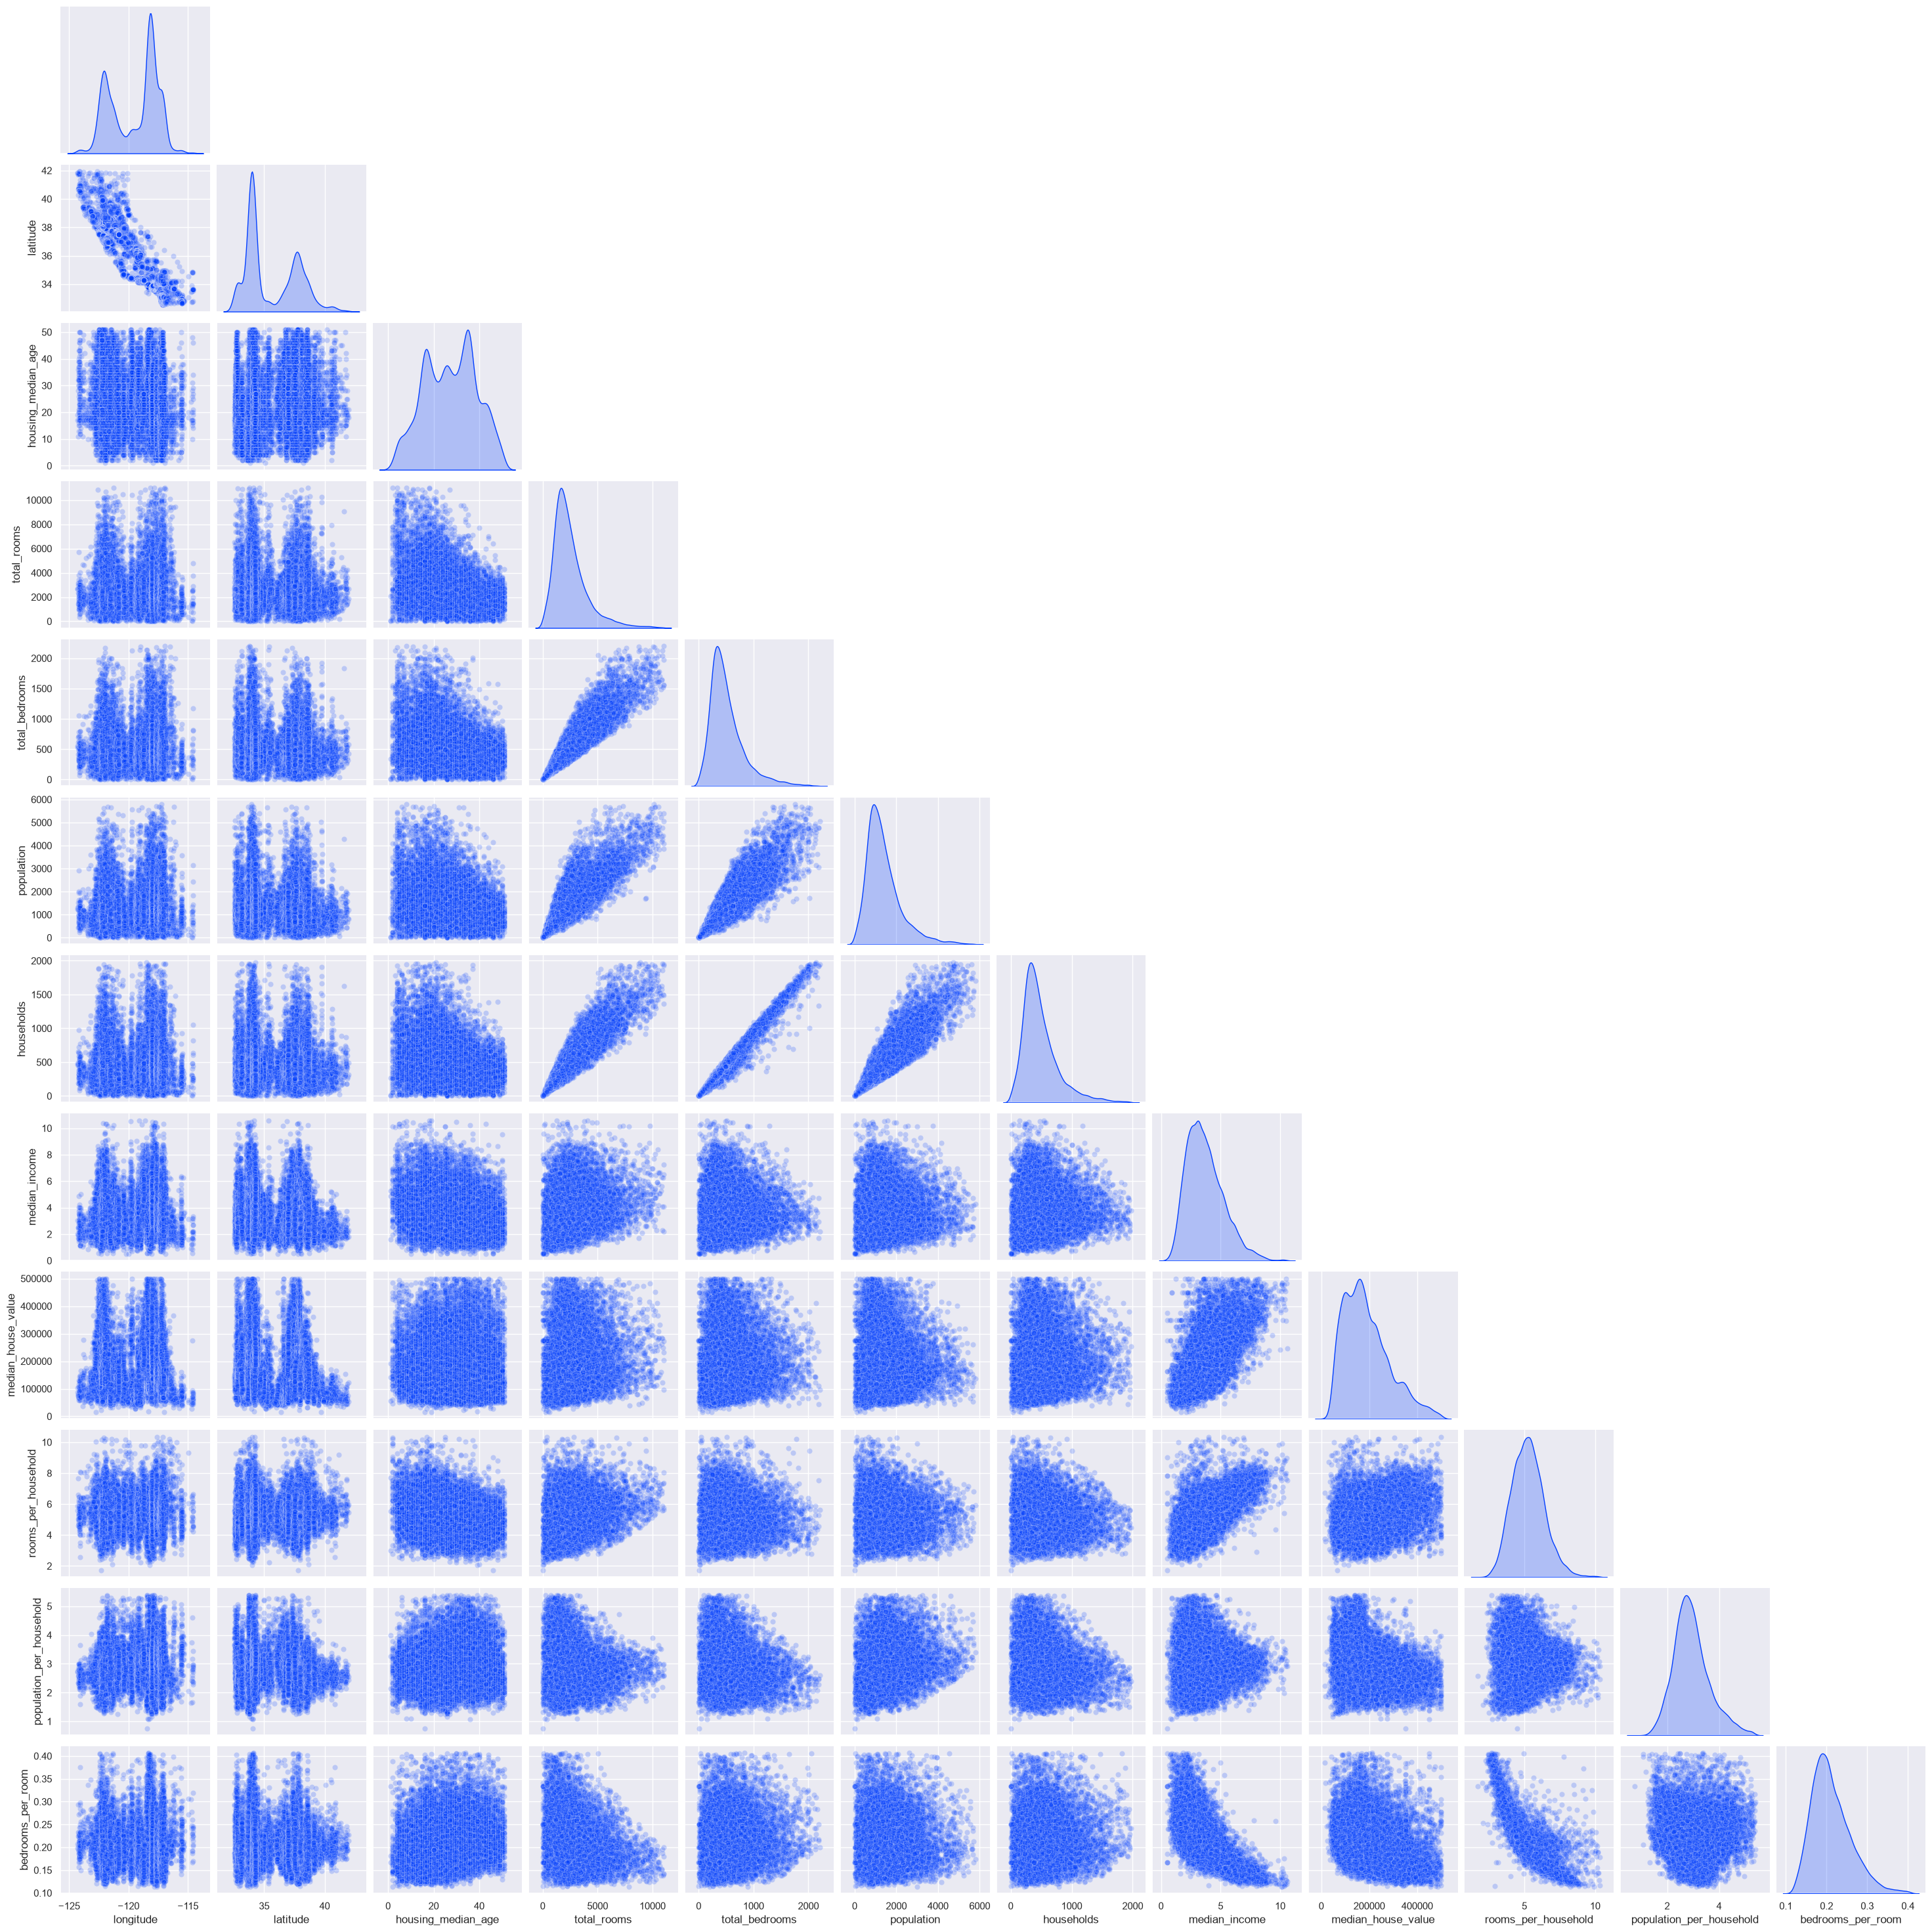

In [32]:
sns.pairplot(df_clean, diag_kind='kde', corner=True, plot_kws=dict(alpha=SCATTER_ALPHA))

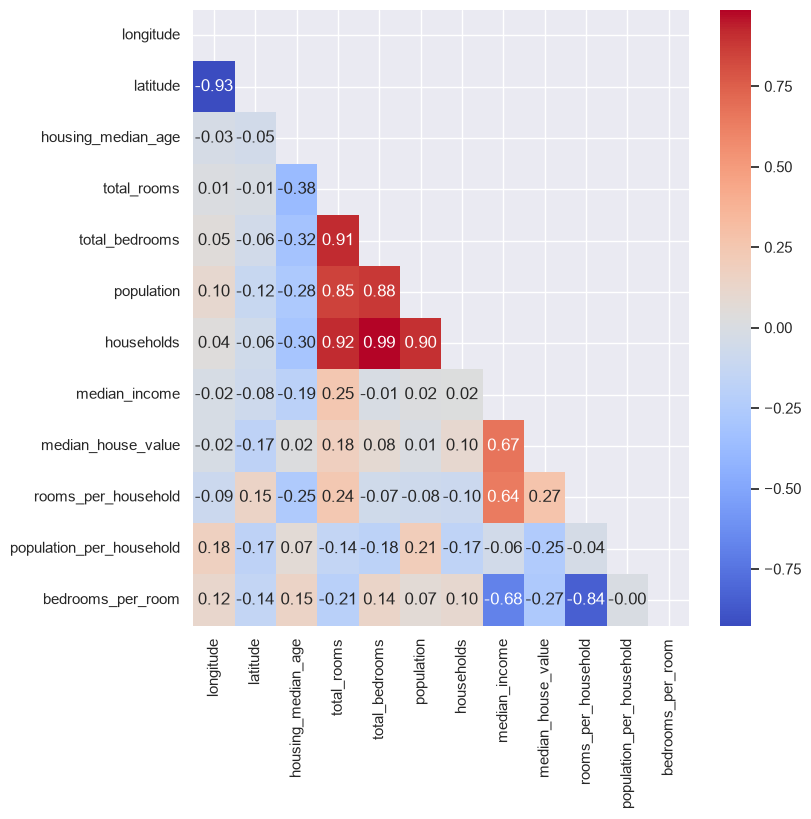

In [33]:
matriz = np.triu(df_clean.select_dtypes('number').corr())

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    df_clean.select_dtypes('number').corr(),
    annot=True,
    fmt='.2f',
    cmap=PALETTE,
    mask=matriz,
    ax=ax,
    
)

plt.show()

In [34]:
df_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7889
INLAND        5935
NEAR OCEAN    2224
NEAR BAY      1516
ISLAND           2
Name: count, dtype: int64

In [35]:
df_clean = df_clean.loc[df_clean["ocean_proximity"] != "ISLAND"]

df_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7889
INLAND        5935
NEAR OCEAN    2224
NEAR BAY      1516
Name: count, dtype: int64

In [36]:
df_clean["ocean_proximity"] = df_clean["ocean_proximity"].astype("category")

df_clean.info()

<class 'pandas.DataFrame'>
Index: 17564 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17564 non-null  float64 
 1   latitude                  17564 non-null  float64 
 2   housing_median_age        17564 non-null  float64 
 3   total_rooms               17564 non-null  float64 
 4   total_bedrooms            17564 non-null  float64 
 5   population                17564 non-null  float64 
 6   households                17564 non-null  float64 
 7   median_income             17564 non-null  float64 
 8   median_house_value        17564 non-null  float64 
 9   ocean_proximity           17564 non-null  category
 10  median_income_cat         17564 non-null  category
 11  rooms_per_household       17564 non-null  float64 
 12  population_per_household  17564 non-null  float64 
 13  bedrooms_per_room         17564 non-null  float64 
dtypes: cat

In [37]:
# Otimização do Dataframe para reduzir o consumo de memória

int_columns = []

for coluna in df_clean.select_dtypes('number').columns:
    if df_clean[coluna].apply(float.is_integer).all():
        int_columns.append(coluna)

int_columns

['housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_house_value']

In [38]:
float_columns = df_clean.select_dtypes('number').columns.difference(int_columns)

float_columns

Index(['bedrooms_per_room', 'latitude', 'longitude', 'median_income',
       'population_per_household', 'rooms_per_household'],
      dtype='str')

In [39]:
df_clean[int_columns] = df_clean[int_columns].apply(pd.to_numeric, downcast='integer')
df_clean[float_columns] = df_clean[float_columns].apply(pd.to_numeric, downcast='float')

df_clean.info()

<class 'pandas.DataFrame'>
Index: 17564 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17564 non-null  float32 
 1   latitude                  17564 non-null  float32 
 2   housing_median_age        17564 non-null  int8    
 3   total_rooms               17564 non-null  int16   
 4   total_bedrooms            17564 non-null  int16   
 5   population                17564 non-null  int16   
 6   households                17564 non-null  int16   
 7   median_income             17564 non-null  float32 
 8   median_house_value        17564 non-null  int32   
 9   ocean_proximity           17564 non-null  category
 10  median_income_cat         17564 non-null  category
 11  rooms_per_household       17564 non-null  float32 
 12  population_per_household  17564 non-null  float32 
 13  bedrooms_per_room         17564 non-null  float32 
dtypes: cat

In [40]:
df_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room
count,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000
mean,-119.509995,35.602200,27.276873,2510.510875,515.378046,1386.315019,483.979447,3.696602,189570.803803,5.253924,2.934664,0.211643
std,1.984251,2.147238,11.323957,1593.977891,320.848886,844.889138,295.559700,1.541926,95971.413796,1.134086,0.691409,0.048315
min,-124.300003,32.540001,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,14999.000000,1.714286,0.750000,0.113535
25%,-121.599998,33.919998,18.000000,1464.750000,300.000000,816.000000,287.000000,2.547375,114300.000000,4.446466,2.470259,0.176919
50%,-118.459999,34.240002,28.000000,2131.000000,438.000000,1196.000000,415.000000,3.479200,171400.000000,5.205450,2.852657,0.203465
75%,-117.980003,37.669998,36.000000,3124.000000,643.000000,1738.000000,605.000000,4.622525,243800.000000,5.961016,3.306427,0.239151
max,-114.550003,41.950001,51.000000,11026.000000,2205.000000,5804.000000,1979.000000,10.594100,500000.000000,10.352942,5.392954,0.406295


## 9. Final preparation for modeling

The dataset is now cleaned and optimized for the next stage of the project. We convert categorical variables appropriately, reduce memory usage, and keep only the most relevant information for modeling.

This final EDA stage prepares the data for regression models and regularization techniques that will be used in the following notebooks.

In [ ]:
df_clean.to_parquet(DADOS_LIMPOS, index=False)